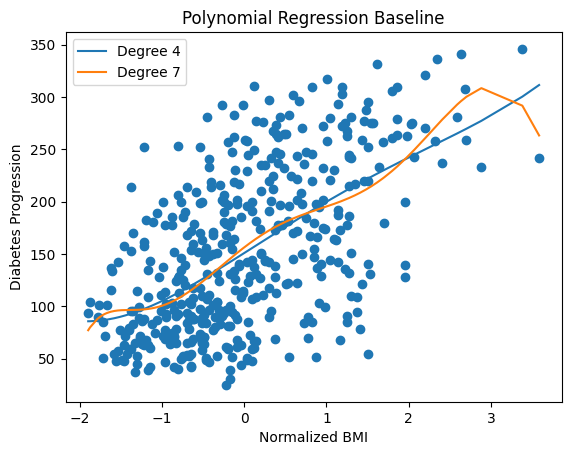

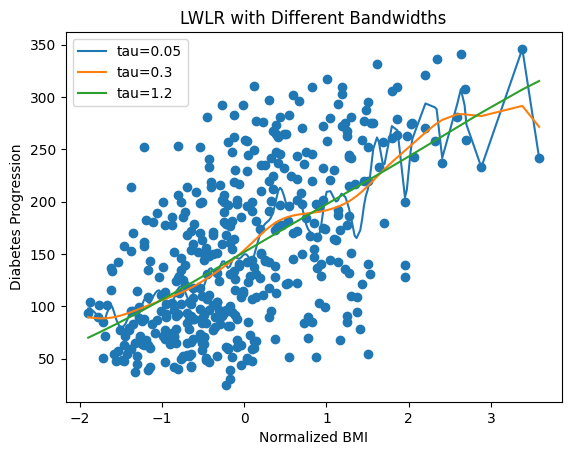

In [7]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
diabetes = load_diabetes()
X = diabetes.data[:, 2].reshape(-1, 1)  # BMI feature
y = diabetes.target

# Normalize
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# Sort for plotting
sort_idx = np.argsort(X_norm[:, 0])
X_sorted = X_norm[sort_idx]
y_sorted = y[sort_idx]

# Polynomial regression degrees 4 and 7
poly4 = PolynomialFeatures(degree=4)
poly7 = PolynomialFeatures(degree=7)

X_poly4 = poly4.fit_transform(X_norm)
X_poly7 = poly7.fit_transform(X_norm)

model4 = LinearRegression().fit(X_poly4, y)
model7 = LinearRegression().fit(X_poly7, y)

y_pred4 = model4.predict(poly4.transform(X_sorted))
y_pred7 = model7.predict(poly7.transform(X_sorted))

# Plot baseline
plt.figure()
plt.scatter(X_norm, y)
plt.plot(X_sorted, y_pred4, label="Degree 4")
plt.plot(X_sorted, y_pred7, label="Degree 7")
plt.xlabel("Normalized BMI")
plt.ylabel("Diabetes Progression")
plt.title("Polynomial Regression Baseline")
plt.legend()
plt.show()

# LWLR functions
def get_weights(x_q, X, tau):
    diff = X - x_q
    w = np.exp(-(diff ** 2) / (2 * tau ** 2))
    return np.diag(w.flatten())

def lwlr_predict(X, y, tau):
    m = X.shape[0]
    X_b = np.hstack([np.ones((m, 1)), X])
    y_pred = np.zeros(m)
    for i in range(m):
        x_q = X[i]
        W = get_weights(x_q, X, tau)
        theta = np.linalg.pinv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y)
        y_pred[i] = np.array([1, x_q[0]]) @ theta
    return y_pred

taus = [0.05, 0.30, 1.20]
plt.figure()
plt.scatter(X_norm, y)

for tau in taus:
    y_lwlr = lwlr_predict(X_norm, y, tau)
    y_lwlr_sorted = y_lwlr[sort_idx]
    plt.plot(X_sorted, y_lwlr_sorted, label=f"tau={tau}")

plt.title("LWLR with Different Bandwidths")
plt.xlabel("Normalized BMI")
plt.ylabel("Diabetes Progression")
plt.legend()
plt.show()
